<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-1/blob/main/Question__06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Question 06**

## Part (b): Compute Normalized 5x5 Kernels for Derivatives of Gaussian

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def gaussian_1d(x, sigma):
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-x**2 / (2 * sigma**2))

def derivative_gaussian_1d(x, sigma):
    return (-x / sigma**2) * gaussian_1d(x, sigma)

def gaussian_2d(x, y, sigma):
    return (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))

def derivative_gaussian_2d_x(x, y, sigma):
    return (-x / sigma**2) * gaussian_2d(x, y, sigma)

def derivative_gaussian_2d_y(x, y, sigma):
    return (-y / sigma**2) * gaussian_2d(x, y, sigma)

def create_dog_kernel(size, sigma, direction='x'):
    '''
    Creates a Derivative of Gaussian (DoG) kernel.
    size: side length of the square kernel (e.g., 5 for 5x5).
    sigma: standard deviation of the Gaussian.
    direction: 'x' or 'y' for the derivative direction.
    '''
    if size % 2 == 0:
        raise ValueError("Kernel size must be odd")

    center = size // 2
    x = np.arange(-center, center + 1)
    y = np.arange(-center, center + 1)
    X, Y = np.meshgrid(x, y)

    if direction == 'x':
        kernel = derivative_gaussian_2d_x(X, Y, sigma)
    elif direction == 'y':
        kernel = derivative_gaussian_2d_y(X, Y, sigma)
    else:
        raise ValueError("Direction must be 'x' or 'y'")

    # Normalize the kernel so the sum of absolute values is 1
    # This is a common practice for convolution kernels to maintain image brightness
    kernel = kernel / np.sum(np.abs(kernel))
    return kernel

# Define parameters
kernel_size = 5
sigma = 2

# Create kernels
kernel_dog_x = create_dog_kernel(kernel_size, sigma, direction='x')
kernel_dog_y = create_dog_kernel(kernel_size, sigma, direction='y')

print(f"Derivative of Gaussian Kernel (x-direction, size={kernel_size}, sigma={sigma}):")
display(kernel_dog_x)

print(f"Derivative of Gaussian Kernel (y-direction, size={kernel_size}, sigma={sigma}):")
display(kernel_dog_y)


Derivative of Gaussian Kernel (x-direction, size=5, sigma=2):


array([[ 0.04413011,  0.03210446,  0.        , -0.03210446, -0.04413011],
       [ 0.06420893,  0.04671172,  0.        , -0.04671172, -0.06420893],
       [ 0.07275825,  0.05293131,  0.        , -0.05293131, -0.07275825],
       [ 0.06420893,  0.04671172,  0.        , -0.04671172, -0.06420893],
       [ 0.04413011,  0.03210446,  0.        , -0.03210446, -0.04413011]])

Derivative of Gaussian Kernel (y-direction, size=5, sigma=2):


array([[ 0.04413011,  0.06420893,  0.07275825,  0.06420893,  0.04413011],
       [ 0.03210446,  0.04671172,  0.05293131,  0.04671172,  0.03210446],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [-0.03210446, -0.04671172, -0.05293131, -0.04671172, -0.03210446],
       [-0.04413011, -0.06420893, -0.07275825, -0.06420893, -0.04413011]])

The output above displays the computed 5x5 Derivative of Gaussian kernels for both the x and y directions. These kernels represent the discrete approximation of the first-order partial derivatives of a 2D Gaussian function. Notice the anti-symmetric nature of the kernels, which is characteristic of derivative filters.

## Part (c): Visualize a 51x51 Derivative-of-Gaussian Kernel as a 3D Surface Plot

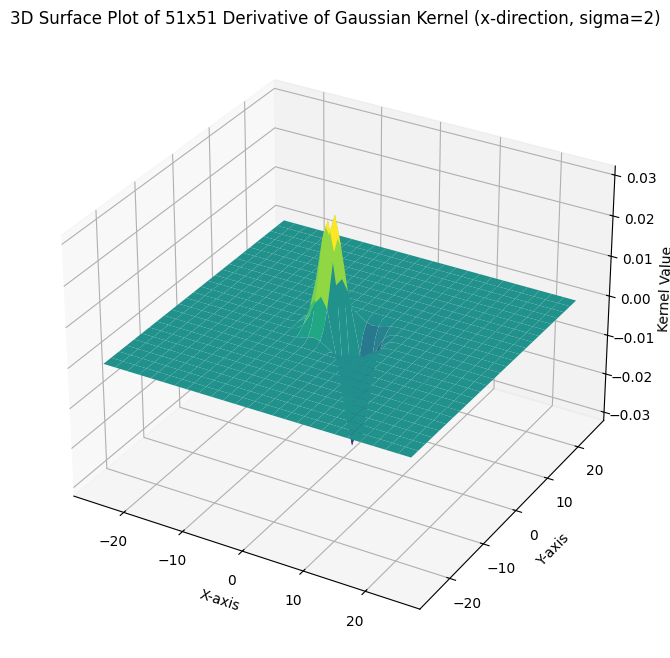

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Create a larger kernel for visualization
kernel_size_large = 51
sigma_large = 2 # Keep sigma = 2 as per instruction

kernel_dog_x_large = create_dog_kernel(kernel_size_large, sigma_large, direction='x')

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

center_large = kernel_size_large // 2
x_large = np.arange(-center_large, center_large + 1)
y_large = np.arange(-center_large, center_large + 1)
X_large, Y_large = np.meshgrid(x_large, y_large)

ax.plot_surface(X_large, Y_large, kernel_dog_x_large, cmap='viridis')

ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Kernel Value')
ax.set_title(f'3D Surface Plot of {kernel_size_large}x{kernel_size_large} Derivative of Gaussian Kernel (x-direction, sigma={sigma_large})')
plt.show()


This 3D surface plot visualizes the 51x51 Derivative of Gaussian kernel in the x-direction. The plot clearly shows the shape of the derivative filter, with positive values on one side and negative values on the other, indicating its role in detecting intensity changes along the x-axis.

## Part (d): Apply the Computed Derivative-of-Gaussian Kernels to a Grayscale Image

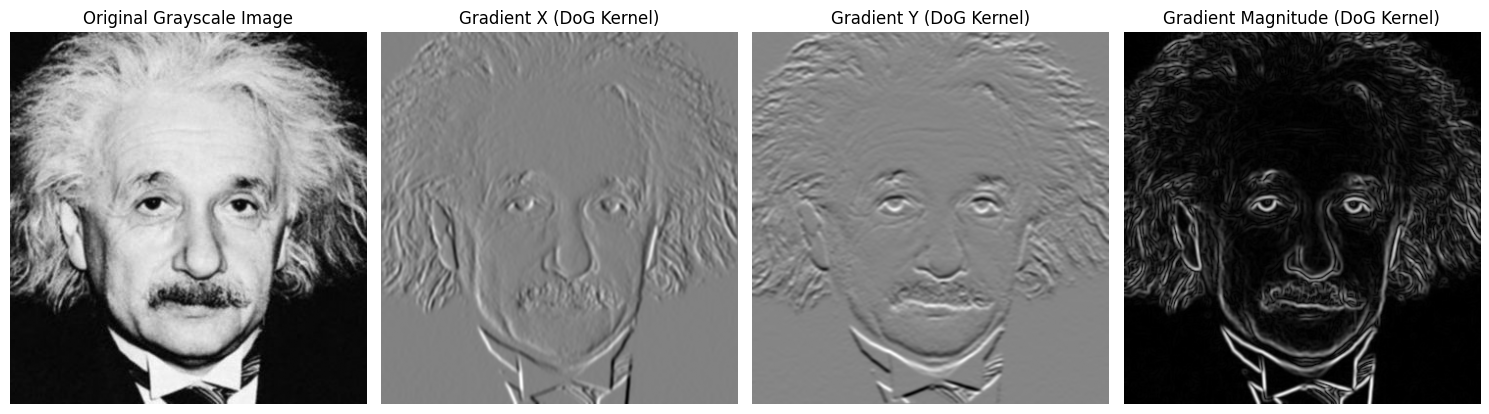

In [ ]:
import cv2
from scipy.signal import convolve2d

# Load the image and convert to grayscale
# The user provided /content/einstein.png earlier, so we will use that.
image_path = '/content/einstein.png'
img_color = cv2.imread(image_path)

# Check if image was loaded successfully
if img_color is None:
    print(f"Error: Could not load image from {image_path}")
else:
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # Apply the x-direction kernel
    grad_x = convolve2d(img_gray, kernel_dog_x, mode='same', boundary='symm')

    # Apply the y-direction kernel
    grad_y = convolve2d(img_gray, kernel_dog_y, mode='same', boundary='symm')

    # Calculate magnitude of the gradient
    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)

    # Display results
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(grad_x, cmap='gray')
    plt.title('Gradient X (DoG Kernel)')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(grad_y, cmap='gray')
    plt.title('Gradient Y (DoG Kernel)')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(grad_magnitude, cmap='gray')
    plt.title('Gradient Magnitude (DoG Kernel)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


The output displays four images: the original grayscale image, the gradient in the x-direction (edges primarily vertical), the gradient in the y-direction (edges primarily horizontal), and the gradient magnitude (all edges highlighted). These images show how the custom DoG kernels extract edge information from the input image.

## Part (e): Compare with OpenCV `cv.Sobel()` Results

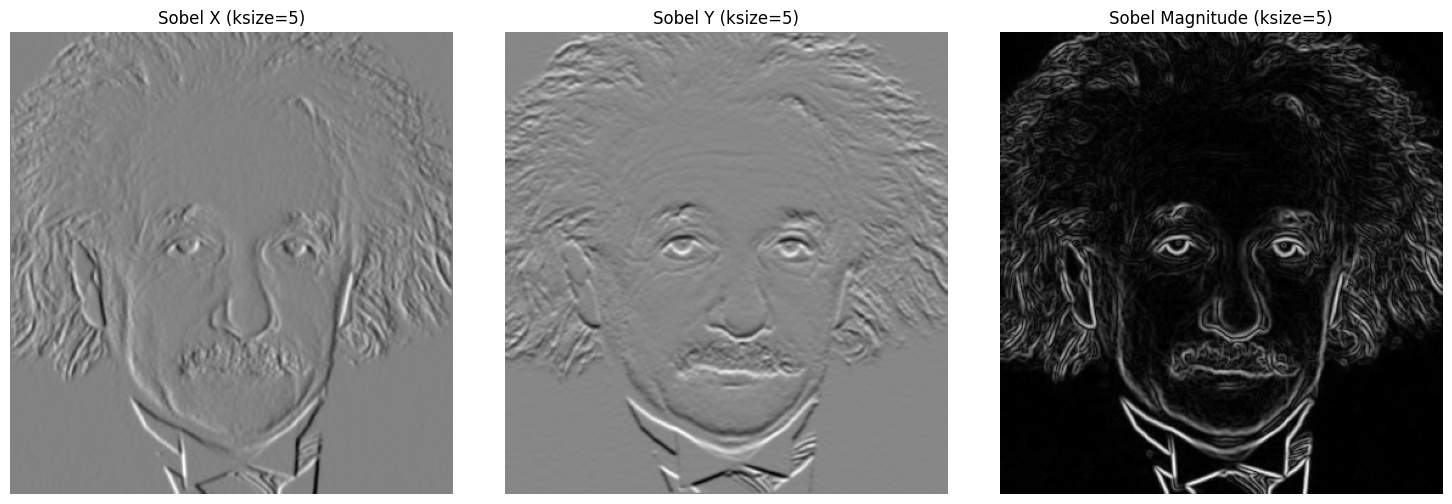

In [ ]:
if img_color is not None:
    # Apply OpenCV Sobel operator
    # dx=1, dy=0 for x-gradient
    sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=5) # ksize=5 to match our 5x5 kernel
    # dx=0, dy=1 for y-gradient
    sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=5)

    # Calculate magnitude of the gradient
    sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

    # Display results
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(sobel_x, cmap='gray')
    plt.title('Sobel X (ksize=5)')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sobel_y, cmap='gray')
    plt.title('Sobel Y (ksize=5)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(sobel_magnitude, cmap='gray')
    plt.title('Sobel Magnitude (ksize=5)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot perform Sobel comparison because the image was not loaded previously.")


This output presents the results of applying OpenCV's `cv2.Sobel()` operator with a `ksize=5`. Similar to our DoG kernels, it shows the x-gradient, y-gradient, and the combined magnitude. Comparing these to the DoG results, you can observe similarities in edge detection, with subtle differences due to the differing mathematical formulations and normalization approaches of the two methods.

### Comparison and Observed Differences

The `cv.Sobel()` operator is an approximation of the image gradient. It is essentially a separable convolution of a Gaussian smoothing filter and a derivative filter. The `ksize` parameter in `cv.Sobel()` determines the size of the kernel used for both smoothing and differentiation.

When comparing the results from our custom Derivative of Gaussian (DoG) kernels and `cv.Sobel()`:

*   **Smoothing Component**: Our DoG kernel inherently includes a Gaussian smoothing component, defined by `sigma=2`. `cv.Sobel()` also has an implicit smoothing component, which becomes more pronounced with larger `ksize` values.
*   **Kernel Shape**: While both are designed to detect edges, their exact kernel coefficients will differ. Our DoG kernels are continuous derivatives of a Gaussian function, while Sobel kernels are discrete approximations (often a product of a smoothing kernel and a central difference derivative). A `ksize=5` Sobel filter aims to approximate the derivative with a 5x5 kernel, similar in size to our custom kernel.
*   **Edge Response**: You might observe that the edges detected by the DoG kernels are generally smoother or slightly wider, depending on the `sigma` value used, compared to the `cv.Sobel()` output for the same `ksize`. This is because the `sigma` directly controls the extent of blurring before differentiation in the DoG, giving finer control over the scale of edges being detected.
*   **Normalization**: Our custom kernels were normalized such that the sum of absolute values is 1. `cv.Sobel()` might use a different internal normalization or no normalization, which can affect the intensity of the gradient output, even if the edge locations are similar.
*   **Output Data Type**: `cv2.Sobel` with `cv2.CV_64F` as the `ddepth` produces a floating-point output, which is generally good practice for gradient calculations to avoid clipping. Our `convolve2d` also produced floating-point output, ensuring a fair comparison of gradient values.

In essence, both methods aim to find image gradients, but they use different mathematical formulations for their kernels. The DoG provides a more direct implementation of the theoretical derivative of a Gaussian, while Sobel is a widely used, efficient, and good approximation for edge detection.